In [2]:
import numpy as np
import pandas as pd
import sqlite3 as sql1
import plotly.express as px

exploring both files, working out relationships, grain of table etc

## scamp_devices

In [3]:
df=pd.read_csv("data/scamp_devices.csv")
df.head(20)

,DeviceID,DeviceIDMonitoring,DeviceName
0,168,B827EB81E46E,Hydroforming 9
1,169,B827EB722606,Hydroforming 5
2,170,B827EB8D8E0C,Hydroforming 8
3,172,B827EBEE1A5E,Hydroforming 4
4,321,B827EB019C33,Hydroforming 12


### since unique hydroforming devices are only 5 and no other particularly useful information is associated with the device ID beside name in the table, name can be referenced with the master device table if needed during the course of analysis and later.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   DeviceID            5 non-null      int64 
 1   DeviceIDMonitoring  5 non-null      object
 2   DeviceName          5 non-null      object
dtypes: int64(1), object(2)
memory usage: 252.0+ bytes


## scamp_report_3m

In [5]:
df=pd.read_csv("data/scamp_report_3m.csv")
df.head()

,ReportID,JobID,DeviceID,StartTime,EndTime,ProductID,CycleTime,QuantityProduced,QuantityScrap,InteruptMinutes
0,291173,13965,168,2023-06-01 01:57:01.000,2023-06-01 03:52:07.000,332,0.38,253.0,0.0,4.250000
1,291201,13965,168,2023-06-01 03:52:07.000,2023-06-01 05:48:39.000,332,0.38,261.0,2.0,0.000000
2,291255,14022,168,2023-06-06 06:00:00.000,2023-06-06 09:59:46.000,332,0.38,520.0,0.0,14.150000
3,291314,14022,168,2023-06-06 09:59:46.000,2023-06-06 13:54:19.000,332,0.38,490.0,7.0,9.933333
4,291323,14022,168,2023-06-06 14:00:00.000,2023-06-06 15:56:31.000,332,0.38,245.0,1.0,4.983333


In [6]:
print(df.info())
print("\n\n")
print("Unique Values")
print(df[["ReportID","JobID","DeviceID","ProductID"]].nunique())
print("\n\n")
print("Period:")
print(f"Start time - from {df["StartTime"].min()} ")
print(f"Start time - to {df["StartTime"].max()} ")
print(f"End time - from {df["EndTime"].min()} ")
print(f"End time - to {df["EndTime"].max()} ")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2793 entries, 0 to 2792
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ReportID          2793 non-null   int64  
 1   JobID             2793 non-null   int64  
 2   DeviceID          2793 non-null   int64  
 3   StartTime         2793 non-null   object 
 4   EndTime           2793 non-null   object 
 5   ProductID         2793 non-null   int64  
 6   CycleTime         2793 non-null   float64
 7   QuantityProduced  2793 non-null   float64
 8   QuantityScrap     2793 non-null   float64
 9   InteruptMinutes   2793 non-null   float64
dtypes: float64(4), int64(4), object(2)
memory usage: 218.3+ KB
None



Unique Values
ReportID     2793
JobID         153
DeviceID        5
ProductID      30
dtype: int64



Period:
Start time - from 2023-06-01 01:55:04.000 
Start time - to 2023-09-05 07:55:25.000 
End time - from 2023-06-01 02:44:00.000 
End time - to 2023-09-

### pre requisites for querying.


In [49]:
conn=sql1.connect("data/hydroforming-scamp-db-sqlite.db")

def run_query(query,conn):
    df=pd.read_sql(query,conn)
    return df

In [50]:
query="""  
SELECT *
FROM scamp_report_3m
"""

df=run_query(query,conn)
df.head(20)

,index,ReportID,JobID,DeviceID,StartTime,EndTime,ProductID,CycleTime,QuantityProduced,QuantityScrap,InteruptMinutes
0,0,291173,13965,168,2023-06-01 01:57:01.000,2023-06-01 03:52:07.000,332,0.38,253.0,0.0,4.250000
1,1,291201,13965,168,2023-06-01 03:52:07.000,2023-06-01 05:48:39.000,332,0.38,261.0,2.0,0.000000
2,2,291255,14022,168,2023-06-06 06:00:00.000,2023-06-06 09:59:46.000,332,0.38,520.0,0.0,14.150000
3,3,291314,14022,168,2023-06-06 09:59:46.000,2023-06-06 13:54:19.000,332,0.38,490.0,7.0,9.933333
4,4,291323,14022,168,2023-06-06 14:00:00.000,2023-06-06 15:56:31.000,332,0.38,245.0,1.0,4.983333
5,5,291339,14022,168,2023-06-06 15:56:31.000,2023-06-06 17:51:31.000,332,0.38,247.0,1.0,2.000000
6,6,291356,14022,168,2023-06-06 17:51:31.000,2023-06-06 19:52:12.000,332,0.38,256.0,4.0,2.133333
7,7,291378,14022,168,2023-06-06 19:52:12.000,2023-06-06 21:52:38.000,332,0.38,261.0,0.0,2.000000
8,8,291396,14022,168,2023-06-06 22:00:00.000,2023-06-07 00:00:26.000,332,0.38,244.0,0.0,7.116667
9,9,291410,14022,168,2023-06-07 00:00:26.000,2023-06-07 00:59:20.000,332,0.38,125.0,3.0,0.000000


#understanding grain of the table
how many unique ids for each id col?
what is the relationship between ids? what does on reportid represent?
what does one jobid represent

#understanding the period and if timestamps have parsed correctly?


#1.first unique counts of all ids

In [51]:
query=""" 
SELECT 
    COUNT(*) AS TotalRow,
    COUNT(DISTINCT(ReportID)) AS DistinctReportID,
    COUNT(DISTINCT(JobID)) AS DistinctJobID,
    COUNT(DISTINCT(DeviceID)) AS DistinctDeviceID,
    COUNT(DISTINCT(ProductID)) AS DistinctJProductID

FROM scamp_report_3m
"""


df=run_query(query,conn)
df.head()

,TotalRow,DistinctReportID,DistinctJobID,DistinctDeviceID,DistinctJProductID
0,2793,2793,153,5,30


#2. For each JobID how many DEVICE and Product ID ONE TO ONE or ONE to MANY?

In [61]:
# change the column names to check different ids relationship 1:1 or 1:many

# query=""" 
# WITH ct AS
# (
# SELECT 
#     JobID,
#     COUNT(DISTINCT(ProductID)) AS ProductIDsCountGroupedByJobID
    

# FROM scamp_report_3m
# GROUP BY JobID

# )

# SELECT 
# COUNT(JobID) AS TotalUniqueJobID,
# SUM(ProductIDsCountGroupedByJobID) AS UniqueProductIDsAgainstJobIDs
# FROM ct
# """


query=""" 

SELECT 
    JobID,
    COUNT(DISTINCT(ProductID)) AS ProductIDsCountGroupedByJobID,
    COUNT(DISTINCT(DeviceID)) AS DeviceIDsCountGroupedByJobID
    

FROM scamp_report_3m
GROUP BY JobID


"""

df=run_query(query,conn)
print(df.head(10))


   JobID  ProductIDsCountGroupedByJobID  DeviceIDsCountGroupedByJobID
0  13965                              1                             1
1  13966                              1                             1
2  13967                              1                             1
3  13989                              1                             1
4  14000                              1                             1
5  14003                              1                             1
6  14019                              1                             1
7  14020                              1                             1
8  14021                              1                             1
9  14022                              1                             1


### this part tells us that it seems one ProductID is associated with one Job at a time, this does not mean that there are 153 ProductID because productID can come again in another job, but that at any one job duration, one product is involved. 

### The next part confirms by summing that all entries of ProductIDsCountGroupedByJobID are 1. Since the sum comes out to be equal to the unique number of JobIDs

In [63]:
query=""" 
WITH ct AS
(
SELECT 
    JobID,
    COUNT(DISTINCT(ProductID)) AS ProductIDsCountGroupedByJobID,
    COUNT(DISTINCT(DeviceID)) AS DeviceIDsCountGroupedByJobID
    

FROM scamp_report_3m
GROUP BY JobID

)

SELECT 
COUNT(JobID) AS TotalUniqueJobID,
SUM(ProductIDsCountGroupedByJobID) AS UniqueProductIDsAgainstJobIDs,
SUM(DeviceIDsCountGroupedByJobID) AS UniqueDeviceIDsAgainstJobIDs
FROM ct
"""


# query=""" 

# SELECT 
#     JobID,
#     COUNT(DISTINCT(ProductID)) AS ProductIDsCountGroupedByJobID
    

# FROM scamp_report_3m
# GROUP BY JobID


# """

df=run_query(query,conn)
print(df.head(10))

   TotalUniqueJobID  UniqueProductIDsAgainstJobIDs  \
0               153                            153   

   UniqueDeviceIDsAgainstJobIDs  
0                           153  


### each unique JobID has only one unique ProductID and one unique DeviceID

### check period of the Dataset

In [53]:
query="""  
    SELECT 
        MIN(strftime('%Y-%m', StartTime) )AS StartingPeriod,
        MAX(strftime('%Y-%m', StartTime) )AS EndingPeriod
    FROM scamp_report_3m
"""

df=run_query(query,conn)
df.head()

,StartingPeriod,EndingPeriod
0,2023-06,2023-09


In [54]:
query=""" 

SELECT Starttime,EndTime,DeviceID,strftime('%m-%d',StartTime) AS DayMonth
FROM scamp_report_3m
WHERE strftime('%m-%d',StartTime) = '06-20'
"""


df=run_query(query,conn)
print(df.head())

# print(df["DeviceID"].unique())
# device_id_map=df["DeviceID"].unique()
# device_id_map={
#     device_id_map[0]:"A",
#     device_id_map[1]:"B",
#     device_id_map[2]:"C",
#     device_id_map[3]:"D",
#     device_id_map[4]:"E",
# }
# print(device_id_map)
# df["DeviceID"]=df["DeviceID"].map(device_id_map)

df["DeviceID"]=df["DeviceID"].astype(str)
fig = px.timeline(
    df,
    x_start="StartTime",
    x_end="EndTime",
    y="DeviceID"
)
fig.show()

                 StartTime                  EndTime  DeviceID DayMonth
0  2023-06-20 01:56:20.000  2023-06-20 03:52:02.000       168    06-20
1  2023-06-20 03:52:02.000  2023-06-20 05:52:57.000       168    06-20
2  2023-06-20 06:00:00.000  2023-06-20 06:59:48.000       168    06-20
3  2023-06-20 06:59:48.000  2023-06-20 07:59:24.000       168    06-20
4  2023-06-20 07:59:24.000  2023-06-20 08:59:32.000       168    06-20


### checking to see if reportID timeline overlap with each other for any machine? or that reportID has a unique time period for a particular device:

### Result : No Overlap


In [65]:
query=""" 
WITH t AS (
    SELECT
        ReportID,
        DeviceID,
        StartTime,
        EndTime,

        LAG(EndTime) OVER (
            PARTITION BY DeviceID
            ORDER BY StartTime
        ) AS PreviousReportEndTime

    FROM scamp_report_3m
),

t2 AS (
SELECT *,
       ROUND(
           (julianday(StartTime) - julianday(PreviousReportEndTime))
           * 24 * 60,
           2
       ) AS GapMinutes

FROM t

ORDER BY DeviceID, StartTime

),

t3 AS
(
SELECT *,
    CASE 
    WHEN GapMinutes < 0 THEN 'overlap'
    WHEN GapMinutes = 0 THEN 'continuous' 
    ELSE 'gap'
    END AS Transitions
FROM t2
)

SELECT DeviceID,Transitions,COUNT(Transitions)
FROM t3
GROUP BY DeviceID, Transitions



"""


df=run_query(query,conn)
print(df.head(20))
print("\n")
print(df["Transitions"].value_counts())

   DeviceID Transitions  COUNT(Transitions)
0       168  continuous                 438
1       168         gap                 152
2       169  continuous                 379
3       169         gap                 149
4       170  continuous                 462
5       170         gap                 158
6       172  continuous                 285
7       172         gap                 133
8       321  continuous                 470
9       321         gap                 167


Transitions
continuous    5
gap           5
Name: count, dtype: int64


### Determining the distribution of these "Gaps" that occur occasionally between reports grouped machine wise: The extreme values in the Gaps are few but strtching the distribution deceptively so placing approximate range of >0 & <40 minutes based on following orignal result
         GapMinutes
count    754.000000
mean     458.249058
std     2179.654324
min        1.350000
25%        7.650000
50%        8.840000
75%       35.767500
max    25929.030000


In [68]:
query=""" 
WITH t AS (
    SELECT
        ReportID,
        DeviceID,
        StartTime,
        EndTime,

        LAG(EndTime) OVER (
            PARTITION BY DeviceID
            ORDER BY StartTime
        ) AS PreviousReportEndTime

    FROM scamp_report_3m
),

t2 AS (
SELECT *,
       ROUND(
           (julianday(StartTime) - julianday(PreviousReportEndTime))
           * 24 * 60,
           2
       ) AS GapMinutes

FROM t

ORDER BY DeviceID, StartTime

),

t3 AS
(
SELECT *,
    CASE 
    WHEN GapMinutes < 0 THEN 'overlap'
    WHEN GapMinutes = 0 THEN 'continuous' 
    ELSE 'gap'
    END AS Transitions
FROM t2
)

SELECT GapMinutes
FROM t3
WHERE GapMinutes > 0 AND GapMinutes < 40



"""


df=run_query(query,conn)
print(df.head(10))
print(df.median())
print(df.describe())


fig=px.histogram(
    df,
    x="GapMinutes",
    nbins=12,
    text_auto=True
)

fig.update_xaxes(categoryorder="category ascending")



fig.show()
# print(df["Transitions"].value_counts())

   GapMinutes
0        5.68
1        7.37
2        7.37
3       12.63
4        5.45
5        7.37
6        8.08
7        8.67
8        7.65
9        7.37
GapMinutes    8.24
dtype: float64
       GapMinutes
count  568.000000
mean     8.796884
std      3.923658
min      1.350000
25%      7.370000
50%      8.240000
75%      9.230000
max     36.600000


## INTERESTED TO SEE  IF JOB ID CHANGED WHEN THESE GAPS OCCURRED

In [15]:
query=""" 
WITH t AS (
    SELECT
        ReportID,
        DeviceID,
        StartTime,
        EndTime,
        JobID,


        LAG(EndTime) OVER (
            PARTITION BY DeviceID
            ORDER BY StartTime
        ) AS PreviousReportEndTime,

        LAG(jobID) OVER (
            PARTITION BY DeviceID
            ORDER BY StartTime
                ) AS PreviousJobID


    FROM scamp_report_3m
),

t2 AS (
SELECT *,
       ROUND(
           (julianday(StartTime) - julianday(PreviousReportEndTime))
           * 24 * 60,
           2
       ) AS GapMinutes

FROM t



),

t3 AS
(
SELECT *,
    CASE 
        WHEN GapMinutes IS NULL THEN 'first_record'
        WHEN GapMinutes < 0 THEN 'overlap'
        WHEN GapMinutes = 0 THEN 'continuous'
        ELSE 'gap'
    END AS Transitions
FROM t2
),

t4 AS
(
SELECT *,
    CASE
    WHEN PreviousJobID IS NULL THEN 'first_record'
    WHEN JobID <> PreviousJobID THEN 'YES'
    ELSE 'NO'
    END AS DidJobChanged
FROM t3
)

SELECT DidJobChanged,Transitions,COUNT(Transitions)
FROM t4
GROUP BY DidJobChanged,Transitions



"""


df=run_query(query,conn)
print(df.head(10))

  DidJobChanged   Transitions  COUNT(Transitions)
0            NO    continuous                1961
1            NO           gap                 673
2           YES    continuous                  73
3           YES           gap                  81
4  first_record  first_record                   5


## INTERESTED TO SEE IF JOB ID RETURNS WITHIN A MACHINE WISE CHRONOLOGICAL SEQUENCE

In [16]:

query=""" 
WITH t AS
(
SELECT DeviceID,JobID,STartTime,LAG(JobID) OVER (PARTITION BY DeviceID ORDER BY StartTime) AS PreviousJobID
FROM scamp_report_3m
),

t2 AS
(
SELECT *, 
    CASE
    WHEN PreviousJobID is NULL THEN '1'
    WHEN JobID <> PreviousJobID THEN '1'
    ELSE 0 END AS BlockIDCreatedOnJobChange
FROM t
),

t3 AS 
(
SELECT *,SUM(BlockIDCreatedOnJobChange) OVER (PARTITION BY DeviceID ORDER BY STartTime) AS BlockID
FROM t2
),

t4 AS
(
SELECT DeviceID,BlockID,COUNT(JobID) AS TotalReportInBlock, COUNT(DISTINCT(JobID)) AS DistinctJobID
FROM t3
GROUP BY DeviceID,BlockID
)

SELECT *
FROM t4

"""



df=run_query(query,conn)
print(df.head(20))




    DeviceID  BlockID  TotalReportInBlock  DistinctJobID
0        168        1                   2              1
1        168        2                  13              1
2        168        3                  23              1
3        168        4                   9              1
4        168        5                   3              1
5        168        6                  44              1
6        168        7                  75              1
7        168        8                  40              1
8        168        9                  19              1
9        168       10                   7              1
10       168       11                   1              1
11       168       12                  13              1
12       168       13                  54              1
13       168       14                   3              1
14       168       15                   9              1
15       168       16                  21              1
16       168       17          

## get jobId that reoccur after other JobIds have run and plot their chronological behaviour

In [17]:
query= """  
WITH t AS (
    SELECT
        DeviceID,
        JobID,
        StartTime,
        EndTime,

        LAG(JobID) OVER (
            PARTITION BY DeviceID
            ORDER BY StartTime
        ) AS PreviousJobID

    FROM scamp_report_3m
),

t2 AS (
    SELECT *,
        CASE
            WHEN PreviousJobID IS NULL THEN 1
            WHEN JobID <> PreviousJobID THEN 1
            ELSE 0
        END AS NewBlock
    FROM t
),

t3 AS (
    SELECT *,
        SUM(NewBlock) OVER (
            PARTITION BY DeviceID
            ORDER BY StartTime
        ) AS BlockID
    FROM t2
)

SELECT
    DeviceID,
    JobID,
    COUNT(DISTINCT BlockID) AS NumberOfBlocks

FROM t3
GROUP BY DeviceID, JobID
HAVING COUNT(DISTINCT BlockID) > 1
ORDER BY NumberOfBlocks DESC
"""

df=run_query(query,conn)
repeating_jobIDs=df["JobID"].tolist()
repeating_jobIDs


[14469, 14218, 14435, 14020, 14328]

In [18]:

query=""" 
SELECT *
FROM scamp_report_3m



"""
df=run_query(query,conn)

mask=df["JobID"].isin(repeating_jobIDs)
df=df[mask]


df["JobID"]=df["JobID"].astype(str)

fig=px.timeline(
    df,
    x_start="StartTime",
    x_end="EndTime",
    y="JobID"

)
fig.show()

### Interesting to see how interruptions are distributed and how interruption may affect throughput. Is there a relationship or pattern between specific products and interruption or may be a pattern between devices and interruption.


In [74]:
query= """  
WITH tp AS
(SELECT 
    DeviceID,
    ProductID,
    SUM((julianday(EndTime) - julianday(StartTime))*24) AS ProductionTimeInHRS,
    SUM(QuantityProduced) AS TotalProduced,
    SUM(((julianday(EndTime) - julianday(StartTime))*24)-(InteruptMinutes/60)) AS ProductionTimeInHRSExcIT


FROM scamp_report_3m
GROUP BY DeviceID,ProductID
),

tp2 AS
(
SELECT *,(TotalProduced/ProductionTimeInHRS) AS RunTimeThroughPut,(TotalProduced/ProductionTimeInHRSExcIT) AS ObservedThroughPut
FROM tp
ORDER BY RunTimeThroughPut DESC
)

SELECT DeviceID,ProductID,ProductionTimeInHRS,((ObservedThroughPut-RunTimeThroughPut)/ObservedThroughPut)*100 AS PercImpactOfInterruptionTime 
FROM tp2



"""

df=run_query(query,conn)
print(df.head())

df["DeviceID"]=df["DeviceID"].astype(str)
df["ProductID"]=df["ProductID"].astype(str)

fig=px.box(
    df,
    x="PercImpactOfInterruptionTime",
    y="ProductID",
    # hover_data=["PercImpactOfInterruptionTime"]
    hover_data=["ProductionTimeInHRS"]
)



fig.update_layout(width=800, height=2000)

fig.show()



   DeviceID  ProductID  ProductionTimeInHRS  PercImpactOfInterruptionTime
0       169        302            22.332778                     15.665563
1       169        443             2.031667                      0.000000
2       172        302           145.676667                     18.917414
3       169        249             2.542500                      7.942751
4       172        495             5.612222                     28.766581


### heatmap would be a better visual for this relationship

In [73]:
heatmap_df = df.pivot(
    index="ProductID",
    columns="DeviceID",
    values="PercImpactOfInterruptionTime"
)

product_order = (
    heatmap_df.max(axis=1, skipna=True)
    .sort_values(ascending=False, kind="stable", na_position="last")
    .index
)
heatmap_df = heatmap_df.loc[product_order]

fig = px.imshow(
    heatmap_df,
    text_auto=".1f",
    aspect="auto",
    labels={
        "x": "Machine",
        "y": "Product",
        "color": "Interruption impact (%)"
    }
)
fig.update_layout(
    height=1000
)
fig.show()

In [23]:
query="""  
WITH t1 AS
(SELECT 
    DeviceID,
    strftime('%W',StartTime) AS WeekOfYearAtStart,
    strftime('%W',EndTime) AS WeekOfYearAtEnd,
    SUM((julianday(EndTime) - julianday(StartTime))*24) AS ReportedHours,
    SUM(InteruptMinutes/60) AS InterruptionHours,
    SUM(((julianday(EndTime) - julianday(StartTime))*24)-(InteruptMinutes/60)) AS EstimatedRunHours
FROM scamp_report_3m
GROUP BY WeekOfYearAtStart,DeviceID
)

SELECT *,InterruptionHours / ReportedHours * 100 AS InterruptionRate
FROM t1
WHERE EstimatedRunHours > 0

"""
df=run_query(query,conn)
print(df.head(20))
# df.head(20)

    DeviceID WeekOfYearAtStart WeekOfYearAtEnd  ReportedHours  \
0        168                22              22       3.860556   
1        169                22              22       3.819444   
2        170                22              22       3.912778   
3        172                22              22       3.801111   
4        321                22              22       3.810278   
5        168                23              23      84.793889   
6        169                23              23      81.011111   
7        170                23              23      99.156944   
8        172                23              23      99.216667   
9        321                23              23     113.726667   
10       168                24              24     107.217778   
11       169                24              24     124.620556   
12       170                24              24     116.991111   
13       172                24              24     106.195278   
14       321             

InteruptMinutes
0.000000    1015
2.000000      40
4.000000      37
3.000000      13
6.000000      10
2.066667       8
2.200000       8
2.033333       8
2.100000       7
2.816667       7
2.266667       7
2.316667       7
2.616667       7
2.650000       7
7.466667       7
2.583333       7
2.133333       7
9.000000       6
3.833333       6
2.850000       6
Name: count, dtype: int64

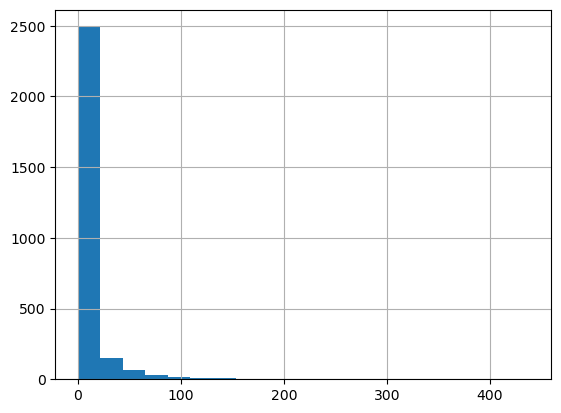

In [ ]:
query="""

SELECT
*,(julianday(EndTime)-julianday(StartTime))*1440 AS ReportDurationMinutes
FROM scamp_report_3m


"""
df=run_query(query,conn)
df["InteruptMinutes"].hist(bins=20)
df["InteruptMinutes"].value_counts().head(20)

<AxesSubplot: >

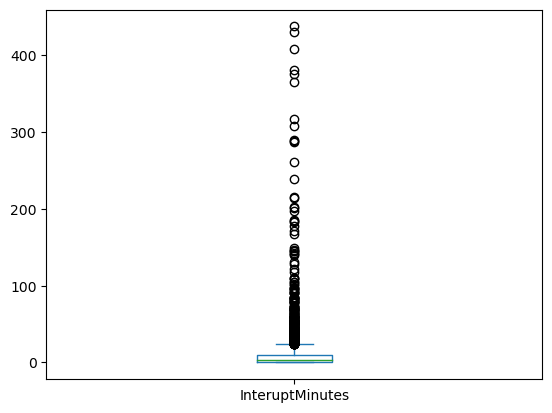

In [25]:
query="""  

SELECT InteruptMinutes
FROM scamp_report_3m

"""

df=run_query(query,conn)
df.plot(kind='box')

checking the interruption time at job end and new job start


<AxesSubplot: title={'center': "WHERE EntryBeforeJobChange = 'Yes'"}>

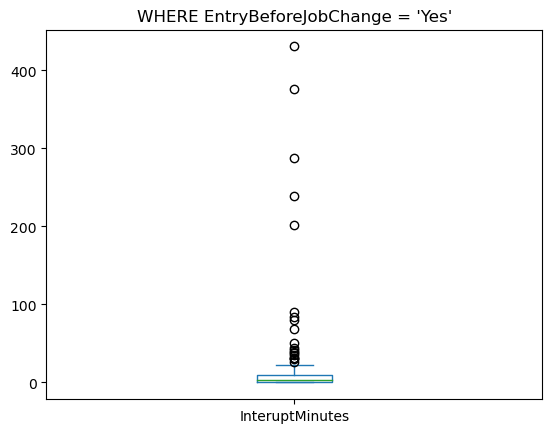

In [26]:
query="""

WITH t1 AS(
SELECT *,LAG(JobID) OVER (PARTITION BY DeviceID ORDER BY StartTime) AS PreviousJobID
FROM scamp_report_3m
),

t2 AS
(SELECT *,
    CASE
    WHEN PreviousJobID IS NULL THEN 'First_record'
    WHEN PreviousJobID <> JobID THEN 'Yes'
    ELSE 'No' 
    END AS JobChanged
FROM t1),

t3 AS
(
SELECT *,LEAD(JobChanged) OVER (PARTITION BY DeviceID ORDER BY StartTime) AS EntryBeforeJobChange
FROM t2
)


SELECT InteruptMinutes
FROM t3
WHERE EntryBeforeJobChange = 'Yes'
"""

df=run_query(query,conn)
df['InteruptMinutes'].plot(kind='box', title="WHERE EntryBeforeJobChange = 'Yes'")

## Product × Machine performance — root-cause direction

### to answer Does the same product perform differently depending on which machine produces it?

In [27]:
query=""" 
WITH t1 AS
(
SELECT ProductID,DeviceID,strftime('%Y-%W',StartTime) AS WeekOfYear,SUM(QuantityProduced) AS QuantityProduced,SUM((julianday(EndTime)-julianday(StartTime))*24) AS TotalReportedHours, SUM(((julianday(EndTime)-julianday(StartTime))*24)-(InteruptMinutes/60.0)) AS EstimatedRunHours
FROM scamp_report_3m
GROUP BY ProductID,DeviceID,strftime('%Y-%W',StartTime)
),

t2 AS
(
SELECT *, (QuantityProduced/TotalReportedHours) AS ObservedThroughput, (QuantityProduced/EstimatedRunHours) AS RunTimeThroughput
FROM t1

)

SELECT *,(RunTimeThroughput - ObservedThroughput)*100/RunTimeThroughput AS EstimatedThroughputLossPct
FROM t2



"""

df=run_query(query,conn)
df.head(10)


,ProductID,DeviceID,WeekOfYear,QuantityProduced,TotalReportedHours,EstimatedRunHours,ObservedThroughput,RunTimeThroughput,EstimatedThroughputLossPct
0,189,169,2023-23,3533.0,24.048333,23.458113,146.912468,150.608874,2.454308
1,189,169,2023-28,3544.0,23.791389,21.210373,148.961459,167.088053,10.848528
2,189,170,2023-30,2074.0,14.241111,14.048889,145.634704,147.627333,1.349770
3,189,170,2023-31,3206.0,18.905833,18.555556,169.577291,172.778443,1.852750
4,189,172,2023-31,2376.0,14.674167,14.357500,161.917201,165.488420,2.157987
5,212,168,2023-23,1810.0,15.286667,12.728581,118.403838,142.199666,16.734096
6,212,168,2023-24,1128.0,8.842778,8.282500,127.561726,136.190763,6.335993
7,212,168,2023-30,1642.0,13.789444,13.403611,119.076588,122.504300,2.798034
8,226,170,2023-36,0.0,3.811667,0.444811,0.000000,0.000000,NaN
9,227,168,2023-28,1986.0,20.459722,16.180967,97.068766,122.736795,20.913067


In [28]:
a=df.groupby(["WeekOfYear","DeviceID"])["ObservedThroughput"].sum().to_frame().reset_index()



fig1=px.line(
    a,
    x="WeekOfYear",
    y="ObservedThroughput",
    color="DeviceID"
)

fig1.show()





In [29]:
b=df.groupby(["WeekOfYear","DeviceID"])["TotalReportedHours"].sum().to_frame().reset_index()

print(df.head(20))

plot_df = b.copy()

plot_df["WeekStart"] = pd.to_datetime(
    plot_df["WeekOfYear"] + "-1",
    format="%Y-%W-%w"
)

fig2=px.line(
    plot_df,
    x="WeekStart",  
    y="TotalReportedHours",
    color="DeviceID"
)

fig2.show()

    ProductID  DeviceID WeekOfYear  QuantityProduced  TotalReportedHours  \
0         189       169    2023-23            3533.0           24.048333   
1         189       169    2023-28            3544.0           23.791389   
2         189       170    2023-30            2074.0           14.241111   
3         189       170    2023-31            3206.0           18.905833   
4         189       172    2023-31            2376.0           14.674167   
5         212       168    2023-23            1810.0           15.286667   
6         212       168    2023-24            1128.0            8.842778   
7         212       168    2023-30            1642.0           13.789444   
8         226       170    2023-36               0.0            3.811667   
9         227       168    2023-28            1986.0           20.459722   
10        227       169    2023-24            3463.0           26.583889   
11        227       169    2023-31               0.0            5.286111   
12        22

/usr/lib/python3/dist-packages/_plotly_utils/basevalidators.py:105: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



In [30]:
df["ProductID"]=df["ProductID"].astype(str)
df["DeviceID"]=df["DeviceID"].astype(str)

a = (
    df.groupby(["ProductID", "DeviceID"], as_index=False)
      .agg(
          QuantityProduced=("QuantityProduced", "sum"),
          TotalReportedHours=("TotalReportedHours", "sum")
      )
)

print(a)

a["ObservedThroughput"] = (
    a["QuantityProduced"] / a["TotalReportedHours"]
)

fig=px.density_heatmap(
    a,
    y="ProductID",
    x="DeviceID",
    z="ObservedThroughput",
    color_continuous_scale="Mint",
    

)

fig.update_yaxes(
    showgrid=True,             # Turn Y-axis grid lines ON (set to False to turn OFF)
    gridwidth=2,               # Change width of the grid lines
)


fig.update_layout(height=1000)

fig.show()

   ProductID DeviceID  QuantityProduced  TotalReportedHours
0        189      169            7077.0           47.839722
1        189      170            5280.0           33.146944
2        189      172            2376.0           14.674167
3        212      168            4580.0           37.918889
4        226      170               0.0            3.811667
5        227      168            1986.0           20.459722
6        227      169            3463.0           31.870000
7        227      170           14396.0          107.187500
8        227      172           16972.0          134.595556
9        232      170             654.0            5.582778
10       238      170             578.0            5.384167
11       244      169            2784.0           19.056944
12       249      169             434.0            2.542500
13       265      169            6515.0           44.645000
14       265      172            1434.0           10.301389
15       290      169            1469.0 

In [31]:
product_id="382"

df_product = df[df["ProductID"] == product_id]
print(df_product.head(10))


fig = px.line(
    df_product,
    x="WeekOfYear",
    y="ObservedThroughput",
    color="DeviceID",
    # barmode="group",
    hover_data=[
        "ProductID",
        "QuantityProduced",
        "TotalReportedHours",
        "EstimatedRunHours",
        "RunTimeThroughput",
        "EstimatedThroughputLossPct"
    ],
    title=f"Weekly Observed Throughput for Product {product_id}",
    labels={
        "WeekOfYear": "Week",
        "ObservedThroughput": "Observed Throughput (units/hour)",
        "DeviceID": "Machine"
    }
)

fig.show()

    ProductID DeviceID WeekOfYear  QuantityProduced  TotalReportedHours  \
117       382      321    2023-22             419.0            3.810278   
118       382      321    2023-23           13591.0          113.726667   
119       382      321    2023-24           17179.0          137.672778   
120       382      321    2023-25           14152.0          110.897778   
121       382      321    2023-26           15089.0          114.000278   
122       382      321    2023-27           17119.0          133.796667   
123       382      321    2023-28           14535.0          108.981389   
124       382      321    2023-29            6416.0           53.708889   
125       382      321    2023-30           11127.0           84.961667   
126       382      321    2023-31           15014.0          112.507778   

     EstimatedRunHours  ObservedThroughput  RunTimeThroughput  \
117           3.027680          109.965736         138.389792   
118         100.783336          119.505833  

## Weekly machine performance
### to calculate Which machines and weeks are losing the most production time?

In [32]:
query = """ 

WITH t1 AS
(
SELECT DeviceID,strftime('%Y-%W',StartTime) AS WeekOfYear,SUM(QuantityProduced) AS QuantityProduced, SUM(QuantityScrap) AS QuantityScrap,SUM((julianday(EndTime)-julianday(StartTime))*24) AS TotalReportedHours, SUM(((julianday(EndTime)-julianday(StartTime))*24)-(InteruptMinutes/60.0)) AS EstimatedRunHours, SUM(InteruptMinutes/60.0) AS InterruptionHours
FROM scamp_report_3m
GROUP BY DeviceID,strftime('%Y-%W',StartTime)
)

SELECT *,(TotalReportedHours-EstimatedRunHours)*100/TotalReportedHours AS InterruptionRate, QuantityScrap/QuantityProduced*100 AS ScrapRate
FROM t1

"""

df=run_query(query,conn)
print(df.head())


df["DeviceID"]=df["DeviceID"].astype(str)


   DeviceID WeekOfYear  QuantityProduced  QuantityScrap  TotalReportedHours  \
0       168    2023-22             514.0            2.0            3.860556   
1       168    2023-23            7873.0           60.0           84.793889   
2       168    2023-24           12462.0          261.0          107.217778   
3       168    2023-25           13008.0           61.0          125.116389   
4       168    2023-26           15892.0          133.0          132.978889   

   EstimatedRunHours  InterruptionHours  InterruptionRate  ScrapRate  
0           3.789722           0.070833          1.834796   0.389105  
1          73.557444          11.236445         13.251479   0.762098  
2          98.929444           8.288333          7.730372   2.094367  
3         108.735350          16.381039         13.092641   0.468942  
4         121.419922          11.558967          8.692332   0.836899  


In [33]:
df.head()


c=df.groupby(["WeekOfYear","DeviceID"], as_index=False).agg(
    QuantityProduced=("QuantityProduced","sum"),
    QuantityScrap=("QuantityScrap","sum"),
)

c["ScrapRate"]=c["QuantityScrap"]/c["QuantityProduced"]*100
c.head(10)


fig=px.line(
    c,
    x="WeekOfYear",
    y="ScrapRate",
    color="DeviceID"
)

fig.show()

In [34]:
df.head()

d=df.groupby(["WeekOfYear","DeviceID"]).agg(
    InterruptionHours=("InterruptionHours","sum"),
    TotalReportedHours=("TotalReportedHours","sum")
                       
).reset_index()
d["InterruptionRate"]=d["InterruptionHours"] / d["TotalReportedHours"] *100

fig=px.line(
    d,
    x="WeekOfYear",
    y="InterruptionRate",
    color="DeviceID"
)

fig.show()

In [35]:


query=""" 
WITH t1 AS
(
SELECT ProductID,DeviceID,strftime('%Y-%W',StartTime) AS WeekOfYear,SUM(QuantityScrap) AS QuantityScrap,SUM(QuantityProduced) AS QuantityProduced,SUM((julianday(EndTime)-julianday(StartTime))*24) AS TotalReportedHours, SUM(((julianday(EndTime)-julianday(StartTime))*24)-(InteruptMinutes/60.0)) AS EstimatedRunHours
FROM scamp_report_3m
GROUP BY ProductID,DeviceID,strftime('%Y-%W',StartTime)
),

t2 AS
(
SELECT *, (QuantityProduced/TotalReportedHours) AS ObservedThroughput, (QuantityProduced/EstimatedRunHours) AS RunTimeThroughput
FROM t1

)

SELECT *,(RunTimeThroughput - ObservedThroughput)*100/RunTimeThroughput AS EstimatedThroughputLossPct
FROM t2



"""

df=run_query(query,conn)
df.head(10)

df["DeviceID"]=df["DeviceID"].astype(str)
df["ProductID"]=df["ProductID"].astype(str)

df=df[df["DeviceID"]=="169"]
df.head(10)

e=df.groupby(["WeekOfYear","ProductID"], as_index=False).agg(
    QuantityProduced=("QuantityProduced","sum"),
    QuantityScrap=("QuantityScrap","sum"),
).sort_values(["WeekOfYear","ProductID"])
e["ScrapRate"]=e["QuantityScrap"]/e["QuantityProduced"]*100
print(e.head(30))

fig=px.box(
    e,
    x="ScrapRate",
    y="ProductID",

)

fig.update_layout(
    height=1000
)

fig.show()


   WeekOfYear ProductID  QuantityProduced  QuantityScrap  ScrapRate
0     2023-22       332             117.0            0.0   0.000000
1     2023-22       443             401.0            0.0   0.000000
2     2023-23       189            3533.0            2.0   0.056609
3     2023-23       332            7621.0           21.0   0.275554
4     2023-24       227            3463.0           17.0   0.490904
5     2023-24       332           14164.0           16.0   0.112962
6     2023-25       302            2680.0            9.0   0.335821
7     2023-25       322            7121.0           54.0   0.758320
8     2023-25       332            1221.0            2.0   0.163800
9     2023-25       370            6011.0           34.0   0.565630
10    2023-26       297           10562.0          972.0   9.202802
11    2023-26       302            2256.0            3.0   0.132979
12    2023-27       297           10746.0          908.0   8.449656
13    2023-28       189            3544.0       

In [36]:
fig=px.line(
    e,
    x="WeekOfYear",
    y="ScrapRate",
    color="ProductID"

)

fig.update_layout(
    height=1000
)

fig.show()

In [37]:
# Device 169 only
d169 = df[df["DeviceID"].astype(str) == "169"].copy()

# Recalculate scrap rate at Product × Week level
d169["ScrapRate"] = (
    d169["QuantityScrap"] / d169["QuantityProduced"] * 100
)

# Total production of Device 169 in each week
weekly_total = (
    d169.groupby("WeekOfYear")["QuantityProduced"]
        .transform("sum")
)

# Each product's share of Device 169 weekly production
d169["ProductionSharePct"] = (
    d169["QuantityProduced"] / weekly_total * 100
)

# Product 297 only
p297 = d169[d169["ProductID"].astype(str) == "297"].copy()



fig = px.bar(
    p297,
    x="WeekOfYear",
    y="ScrapRate",
    text_auto=".1f",
    title="Product 297 Scrap Rate on Device 169",
    labels={
        "WeekOfYear": "Week",
        "ScrapRate": "Scrap Rate (%)"
    }
)

fig.show()


fig = px.bar(
    p297,
    x="WeekOfYear",
    y="ProductionSharePct",
    text_auto=".1f",
    title="Product 297 Share of Device 169 Weekly Production",
    labels={
        "WeekOfYear": "Week",
        "ProductionSharePct": "Share of Weekly Production (%)"
    }
)

fig.show()

In [38]:


query=""" 
WITH t1 AS
(
SELECT ProductID,DeviceID,strftime('%Y-%W',StartTime) AS WeekOfYear,SUM(QuantityScrap) AS QuantityScrap,SUM(QuantityProduced) AS QuantityProduced,SUM((julianday(EndTime)-julianday(StartTime))*24) AS TotalReportedHours, SUM(((julianday(EndTime)-julianday(StartTime))*24)-(InteruptMinutes/60.0)) AS EstimatedRunHours
FROM scamp_report_3m
GROUP BY ProductID,DeviceID,strftime('%Y-%W',StartTime)
),

t2 AS
(
SELECT *, (QuantityProduced/TotalReportedHours) AS ObservedThroughput, (QuantityProduced/EstimatedRunHours) AS RunTimeThroughput
FROM t1

)

SELECT *,(RunTimeThroughput - ObservedThroughput)*100/RunTimeThroughput AS EstimatedThroughputLossPct
FROM t2



"""

df=run_query(query,conn)

df["DeviceID"]=df["DeviceID"].astype(str)
df["ProductID"]=df["ProductID"].astype(str)
df.head(10)

df=df[df["ProductID"]=="297"]

f=df.groupby(["WeekOfYear","DeviceID"], as_index=False).agg(
    QuantityProduced=("QuantityProduced","sum"),
    QuantityScrap=("QuantityScrap","sum"),
).sort_values(["WeekOfYear","DeviceID"])
f["ScrapRate"]=f["QuantityScrap"]/f["QuantityProduced"]*100


f.head()

fig=px.line(
    f,
    x="WeekOfYear",
    y="ScrapRate",
    color="DeviceID",

)

fig.update_layout(
    height=1000
)

fig.show()

## Job-Transition Interruption Analysis
### Are recorded interruptions systematically different immediately before or after a job change compared with normal within-job production?

In [39]:
query = """ 

WITH t1 AS
(
SELECT *,LAG(JobID) OVER (PARTITION BY DeviceID ORDER BY StartTime ) AS PreviousJobID
FROM scamp_report_3m
),

t2 AS
(
SELECT *,
    CASE WHEN PreviousJobID <> JobID THEN 1
    ELSE 0 END AS FirstAfterJobChange
FROM t1
),

t3 AS
(
SELECT *, LEAD(FirstAfterJobChange) OVER (PARTITION BY DeviceID ORDER BY StartTime) AS LastBeforeJobChange
FROM t2
)


SELECT ReportID,DeviceID,InteruptMinutes,
    CASE 
    WHEN FirstAfterJobChange = 1 THEN 'First After Job Change'
    WHEN LastBeforeJobChange = 1 THEN 'Last Before Job Change'
    ELSE 'Neither' END AS JobChangeStatus
FROM t3



"""
df=run_query(query,conn)
print(df.head())

   ReportID  DeviceID  InteruptMinutes         JobChangeStatus
0    291173       168         4.250000                 Neither
1    291201       168         0.000000  Last Before Job Change
2    291255       168        14.150000  First After Job Change
3    291314       168         9.933333                 Neither
4    291323       168         4.983333                 Neither


In [40]:
df["DeviceID"] = df["DeviceID"].astype(str)

fig = px.box(
    df,
    x="JobChangeStatus",
    y="InteruptMinutes",
    facet_col="DeviceID",
    facet_col_wrap=2,
    points="outliers",
    title="Interruption Duration Around Job Changes by Machine",
    labels={
        "JobChangeStatus": "Position Relative to Job Change",
        "InteruptMinutes": "Interruption (minutes)",
        "DeviceID": "Machine"
    }
)

fig.update_layout(height=1000)
fig.show()

In [41]:
f=df[df["JobChangeStatus"]=="Neither"]
px.histogram(
    df,
    x="InteruptMinutes",
    nbins=20
)